# Modelo de machine learning

In [1]:
import pandas as pd

df = pd.read_csv('../data/clean/bank_marketing_clean.csv')

df

,age,balance,duration,campaign,pdays,previous,y,job_unknown,education_unknown,contact_unknown,...,day_of_week_25,day_of_week_26,day_of_week_27,day_of_week_28,day_of_week_29,day_of_week_30,day_of_week_31,poutcome_failure,poutcome_other,poutcome_success
0,58,2143.0,261,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,44,29.0,151,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,33,2.0,76,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,47,1506.0,92,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,33,1.0,198,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825.0,977,3,-1,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
45207,71,1729.0,456,2,-1,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
45208,72,5715.0,1127,5,184,3,1,0,0,0,...,False,False,False,False,False,False,False,False,False,True
45209,57,668.0,508,4,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


## Hacer split de datos

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop('y', axis=1)
y = df['y']

X.head(5)

,age,balance,duration,campaign,pdays,previous,job_unknown,education_unknown,contact_unknown,poutcome_unknown,...,day_of_week_25,day_of_week_26,day_of_week_27,day_of_week_28,day_of_week_29,day_of_week_30,day_of_week_31,poutcome_failure,poutcome_other,poutcome_success
0,58,2143.0,261,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,44,29.0,151,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,33,2.0,76,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,47,1506.0,92,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,33,1.0,198,1,-1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [4]:
y.head(5)

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

## Implementacion de modelo no supervisado:
Se utilizo para esto punto K Means, porque necesitamos perfiles concretos de clientes, mas que reducir la dimensionabilidad, que es lo que lograriamos usando PCA

k (silhouette-max) = 2 | k (elbow-dist) = 5 | k (log-2ª derivada) = 9


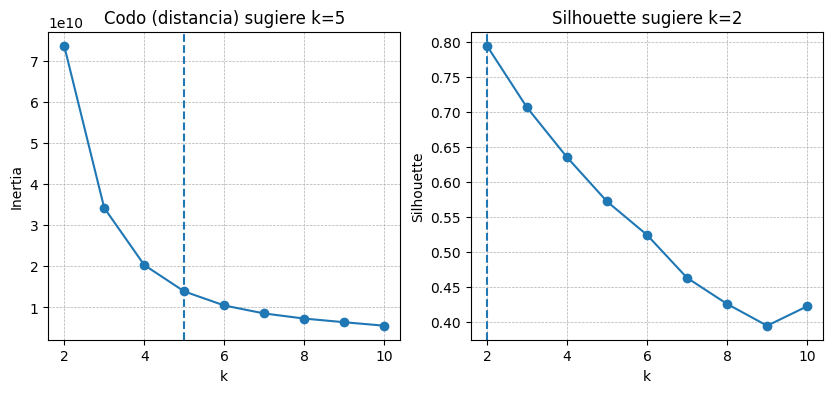

In [6]:
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

def scan_kmeans(X, kmin=2, kmax=10, seed=42):
    out = []
    for k in range(kmin, kmax+1):
        km = KMeans(n_clusters=k, n_init=50, random_state=seed).fit(X)
        sil = silhouette_score(X, km.labels_)
        out.append((k, km.inertia_, sil))
    return pd.DataFrame(out, columns=["k","inertia","silhouette"])

def elbow_k_by_distance(k_vals, inertia_vals, use_log=True):
    k = np.asarray(k_vals, dtype=float); y = np.asarray(inertia_vals, dtype=float)
    if use_log: y = np.log(y)
    x1,y1 = k[0], y[0]; x2,y2 = k[-1], y[-1]
    num = np.abs((y2 - y1)*k - (x2 - x1)*y + (x2*y1 - y2*x1))
    den = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
    return int(k[np.argmax(num/den)])

km_grid = scan_kmeans(X, 2, 10)

logI = np.log(km_grid['inertia'].values); kvals = km_grid['k'].values
d2 = np.diff(np.diff(logI)); k_log2 = int(kvals[np.argmin(d2)+1])

k_dist = elbow_k_by_distance(km_grid['k'].values, km_grid['inertia'].values, use_log=True)

k_sil = int(km_grid.loc[km_grid['silhouette'].idxmax(),'k'])

print(f"k (silhouette-max) = {k_sil} | k (elbow-dist) = {k_dist} | k (log-2ª derivada) = {k_log2}")

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(km_grid['k'], km_grid['inertia'], marker='o'); ax[0].axvline(k_dist, ls='--')
ax[0].set_title(f'Codo (distancia) sugiere k={k_dist}'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia'); ax[0].grid(True, ls='--', lw=0.5)
ax[1].plot(km_grid['k'], km_grid['silhouette'], marker='o'); ax[1].axvline(k_sil, ls='--')
ax[1].set_title(f'Silhouette sugiere k={k_sil}'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette'); ax[1].grid(True, ls='--', lw=0.5)
plt.show()

k_opt = k_sil

## Se van a usar el numero de cluster senalados por el metodo del codo (5), para obtener mayor profundidad en los perfiles de los clientes

In [8]:
pipeline_weighted_kmeans = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=5, n_init=50, random_state=42))
])

pipeline_weighted_kmeans.fit(X_train, y_train)

pipeline_weighted_kmeans

,steps,"[('scaler', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,5
,init,'k-means++'
,n_init,50
,max_iter,300


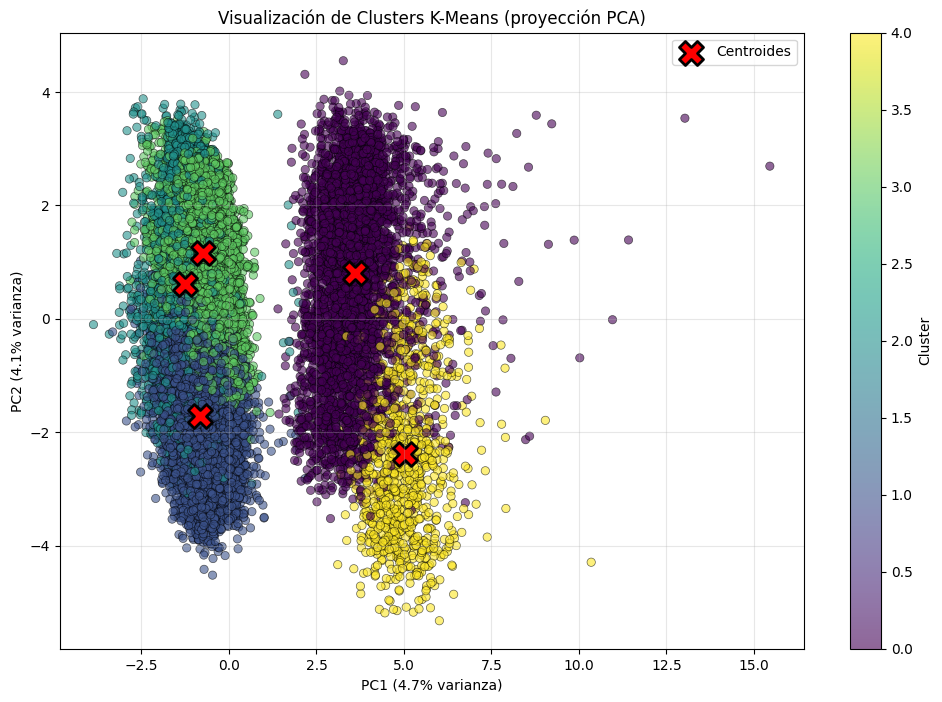

Varianza explicada por PC1+PC2: 8.8%


In [11]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

clusters_train = pipeline_weighted_kmeans.fit_predict(X_train_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=clusters_train, 
                     cmap='viridis', 
                     alpha=0.6, 
                     edgecolors='k', 
                     linewidth=0.5)

kmeans_model = pipeline_weighted_kmeans.named_steps['kmeans']
centroids_pca = pca.transform(kmeans_model.cluster_centers_)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='red', 
           marker='X', 
           s=300, 
           edgecolors='black', 
           linewidth=2,
           label='Centroides')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Visualización de Clusters K-Means (proyección PCA)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Varianza explicada por PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

### NOTA: La baja varianza explicada (8.8%) es esperada debido a la alta dimensionalidad post One-Hot Encoding (143 features). Los clusters K-Means se calculan en el espacio original completo, no en esta proyección 2D.
### Esta visualización es solo ilustrativa para inspección visual.